(flux-uncertainty-doc)=
# Measurement biases

$\mathrm{LiMe}$'s main purpose is the measurement of line fluxes. This value represents the magnitude of
photons emitted or absorbed via one or several transitions in the plasma of an astronomical source.
Due to the time constraints on astronomical observations, most spectra are constrained from the S/N point of view. Moreover,
astronomers are more likely than not to test the limits of the telescope spectrographs. This means that understanding how the pipeline
calibration uncertainty propagates to our line fluxes is essential to validate our conclusions.

Moreover, by default $\mathrm{LiMe}$ assumes the user will provide the minimum amount of inputs, and the functions' defaults are conceived to provide the best analysis for this case. However, as the complexity of the input data increases, these defaults may not be ideal.

In this documentation page, we want to compile a list of the main biases in spectral analysis and explain how the user's judgement is essential to maximize the quality of the analysis.

<div class="alert alert-success">

These examples are part of $\mathrm{LiMe}$'s testing framework coverage
([![Code cov](https://codecov.io/gh/Vital-Fernandez/lime/branch/master/graph/badge.svg?token=4ZW8EATXN7)](https://codecov.io/gh/Vital-Fernandez/lime)),
where $\mathrm{LiMe}$ compares the integrated and profile measurements against reference tools and confirms that the
function results from new versions remain consistent as new features and bug fixes are introduced.
However, the authors welcome any reports of incorrect or missing measurements so that we can continue to improve the package.

</div>



## 1) Line profile selection

```{image} ../0_resources/images/flux_methodology.png
:width: 1000px
:align: center
:class: only-light
```
```{image} ../0_resources/images/flux_methodology_dark.png
:width: 1000px
:align: center
:class: only-dark
```
<span style="font-size: 0.85em; font-style: italic;">Figure 1: Comparison between the integrated line band flux and the multi-profile fit flux.</span>

$\mathrm{LiMe}$ provides two distinct approaches to measure line fluxes, which are illustrated in the figure above:

- **Integrated bands (left Fig.1):** In this approach, we integrate the area under the spectrum pixels for a band with a certain velocity
dispersion (width) and systemic velocity (central location). This measurement provides a result for every transition
computed under certain kinematic conditions. The uncertainty in this measurement represents the pixel flux error
propagation from the band.
- **Multi-profile fit (right Fig.1):** In this approach, we fit one or more theoretical profiles to the pixels inside
the line band. Assuming that the emitting or absorbing plasma dynamics match the theoretical distribution, this measurement
represents the resolved kinematics and photon count of each transition contribution.

By default, $\mathrm{LiMe}$ assumes that a line has an emission shape with a single Gaussian propile. In Fig. 1 example, it is easy to appreciate how the results from both techniques are distinctly different in magnitude and scientific value; however, in many cases the impact of the profile selection can be easy to miss:

### 1.1) Comparison with SDSS DR18 measurements

To illustrate these differences, we are going to measure the [OIII]4959Å line in the SDSS spectrum of the compact
star-forming galaxy SHOC579. The SDSS pipeline provides its own line measurements in the ``SPZLINE`` extension of the
observation *.fits* file, where each line flux (``LINEAREA``) is computed from a single Gaussian profile fit.

Let's start by loading the observation, the configuration file and the SDSS measurements:

In [43]:
import numpy as np
import pandas as pd
from astropy.io import fits
import lime
from lime.tools import au


# State the data files
cfgFile = '../0_resources/long_slit.toml'
sdss_fits_fname = '../0_resources/spectra/SHOC579_SDSS_dr18.fits'

# Load configuration
obs_cfg = lime.load_cfg(cfgFile)

# Load the observation
spec_single = lime.Spectrum.from_file(sdss_fits_fname, instrument='sdss')
line_flux_units = f'{spec_single.units_flux * au.Unit('AA')}'

# Unpack the SDSS line measurements into a dataframe
sdss_lines = fits.getdata(sdss_fits_fname, extname='SPZLINE')
sdss_df = pd.DataFrame(sdss_lines.tolist(), columns=sdss_lines.names)
sdss_df['LINENAME'] = sdss_df['LINENAME'].str.strip()
sdss_df.set_index('LINENAME', inplace=True)

# SDSS [OIII]4959Å flux
sdss_flux, sdss_err = sdss_df.loc['[O_III] 4959', ['LINEAREA', 'LINEAREA_ERR']]
print(f'SDSS file stored [OIII]4959Å flux: {sdss_flux:.2f} ± {sdss_err:.2f} {line_flux_units}')

SDSS file stored [OIII]4959Å flux: 12517.86 ± 51.11 1e-17 erg / (s cm2)


#### 1.1.1) Single component fit

In our first measurement, we do not provide a fitting configuration, hence $\mathrm{LiMe}$ fits a single Gaussian profile
to the line band:


Line fitting progress:
[==========] 100% of 1 lines (O3_4959A)

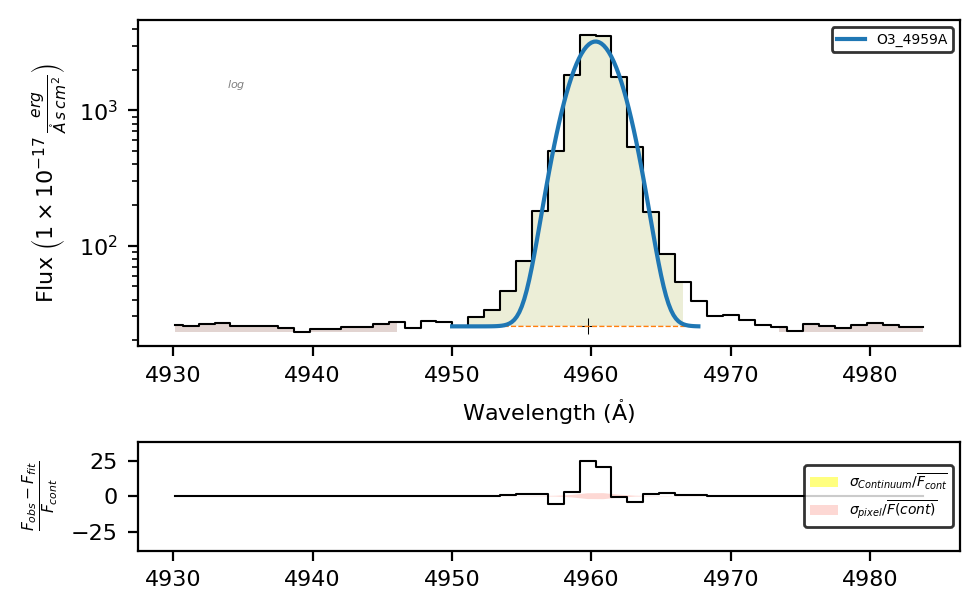

In [44]:
# Line bands without grouping and fit a single Gaussian profile
bands_single = spec_single.retrieve.lines_frame(band_vsigma=120)
spec_single.fit.frame(bands_single, cont_source='adjacent', line_list=['O3_4959A'])
spec_single.plot.bands('O3_4959A', rest_frame=True)

Even in the logarithmic scale the fitted profile seems ok. However, once we compare the flux measurements:

In [45]:
# Compare the LiMe measurements with SDSS
single = spec_single.frame.loc['O3_4959A']
print(f'SDSS flux:            {sdss_flux:.2f} ± {sdss_err:.2f} {line_flux_units}')
print(f'LiMe profile flux:    {single.profile_flux:.2f} ± {single.profile_flux_err:.2f} {line_flux_units}')
print(f'LiMe integrated flux: {single.intg_flux:.2f} ± {single.intg_flux_err:.2f} {line_flux_units}')

SDSS flux:            12517.86 ± 51.11 1e-17 erg / (s cm2)
LiMe profile flux:    12533.33 ± 888.96 1e-17 erg / (s cm2)
LiMe integrated flux: 13843.98 ± 92.21 1e-17 erg / (s cm2)


The profile flux is in good agreement with the SDSS measurement, which is expected since both come from a single Gaussian fit. However, the integrated flux is larger than both of them. What's the source for this discrepancy?

#### 1.1.2) Two components fit

Our configuration file includes a second kinematic component for this line:

In [46]:
{key: value for key, value in obs_cfg['SHOC579_sdss_line_fitting'].items() if key.startswith('O3_4959A')}

{'O3_4959A_b': 'O3_4959A+O3_4959A_k-1',
 'O3_4959A_k-1_sigma': {'expr': '>2.0*O3_4959A_sigma'}}

Once we included in the fitting function, [OIII]4959Å line will be fitted with two Gaussian profiles:


Line fitting progress:
[==========] 100% of 1 lines (O3_4959A_b)

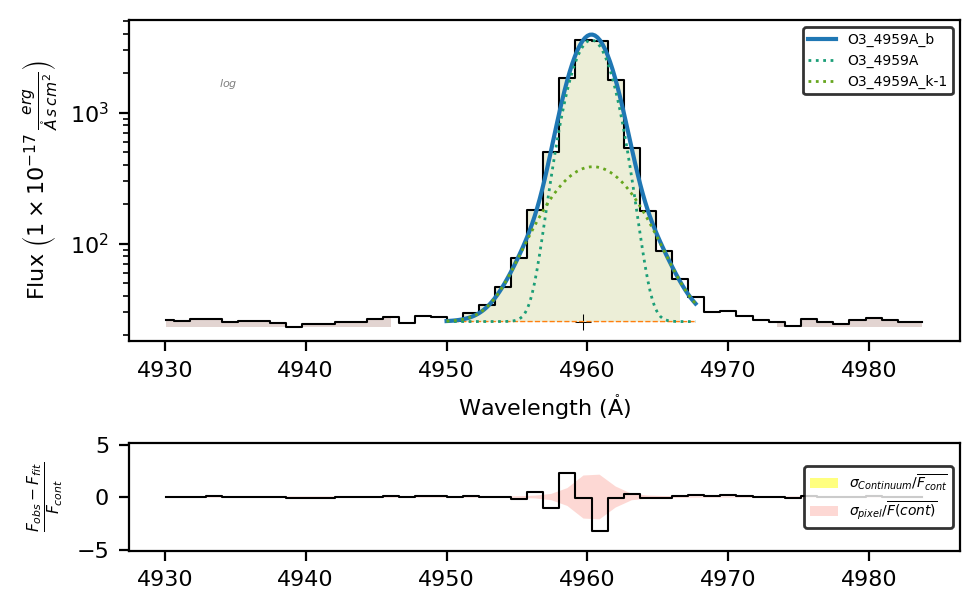

In [47]:
# Load the observation
spec_double = lime.Spectrum.from_file(sdss_fits_fname, instrument='sdss')

# Line bands with the configuration groups and fit two Gaussian profiles
bands_double = spec_double.retrieve.lines_frame(band_vsigma=120, fit_cfg=obs_cfg, obj_cfg_prefix='SHOC579_sdss')

# Fit the line
spec_double.fit.frame(bands_double, fit_cfg=obs_cfg, obj_cfg_prefix='SHOC579_sdss', cont_source='adjacent', line_list=['O3_4959A_b'])

spec_double.plot.bands(rest_frame=True)

The two components reproduce the line shape much better. Let's compare the fluxes from both measurements with SDSS:

In [48]:
# Kinematic components of [OIII]4959Å
double = spec_double.frame.loc[spec_double.frame.index.str.startswith('O3_4959A')]

# Sum of the profile fluxes (the error neglects the covariance between the components)
double_flux = double.profile_flux.sum()
double_err = np.sqrt(np.sum(np.square(double.profile_flux_err)))

# In blended groups the integrated flux is computed for the whole band (same value for every component)
print(f'{"SDSS flux:":<33}{sdss_flux:.2f} ± {sdss_err:.2f} {line_flux_units}')
for line, row in double.iterrows():
    print(f'{f"LiMe profile flux {line}:":<33}{row.profile_flux:.2f} ± {row.profile_flux_err:.2f} {line_flux_units}')
print(f'{"LiMe profile flux (sum):":<33}{double_flux:.2f} ± {double_err:.2f} {line_flux_units}')
print(f'{"LiMe integrated flux:":<33}{double.intg_flux.iloc[0]:.2f} ± {double.intg_flux_err.iloc[0]:.2f} {line_flux_units}')

SDSS flux:                       12517.86 ± 51.11 1e-17 erg / (s cm2)
LiMe profile flux O3_4959A:      11472.85 ± 215.16 1e-17 erg / (s cm2)
LiMe profile flux O3_4959A_k-1:  2446.69 ± 232.43 1e-17 erg / (s cm2)
LiMe profile flux (sum):         13919.54 ± 316.73 1e-17 erg / (s cm2)
LiMe integrated flux:            13844.57 ± 92.30 1e-17 erg / (s cm2)


The integrated flux has not changed between the two measurements: it only depends on the line band and the continuum. In contrast, the double profile matches the observed line, and the sum of the two components' areas agrees with the integrated flux. The uncertainty values, however, are not similar, nor do they have the same mathematical meaning:

- **Integrated flux uncertainty:** This parameter represents the propagation of the pixel flux error as we sum up their
fluxes. The integration is performed by generating a grid of 1,000 realizations of the line shape, assuming the pixel
distribution follows a Gaussian distribution. Across these realizations, the mean sum of the pixels represents the line
flux, while the standard deviation represents the line flux uncertainty.
- **Multi-profile fit flux uncertainty:** For each of the profile parameters ($A$, $\mu$ and $\sigma$ for a Gaussian
profile), the $1\sigma$ uncertainty reported by the minimizer represents the amount by which each parameter must
increase/decrease such that the $\chi^2$ increases by 1. The individual component's flux — computed from the theoretical
relation ($F_{\mathrm{Gaussian},\,i}=\sqrt{2\pi}A_{i}\sigma_{i}$ for a Gaussian profile) — is obtained by drawing a grid of
1,000 parameter values from their $1\sigma$ uncertainty distributions. The final line flux uncertainty is the standard deviation of the
resulting theoretical flux array.

<div class="alert alert-danger">

**Please note** that in both SDSS and $\mathrm{LiMe}$ single-Gaussian fits, the profile uncertainty is smaller than the flux missed from the second component. To the authors' best knowledge, there is no algorithm in the literature that can automatically decide the optimum type and number of profiles given the nature of the astronomical source. At present, this requires a careful comparison between measurements and their AIC and BIC values.

</div>

## 2) Calibration flux uncertainty

 $\mathrm{LiMe}$ has two methodologies to extract the line pixel flux uncertainty:

- **Spectrum uncertainty:** The error array provided with the observation (`.err_flux`) is used directly. This is the
  default whenever the spectrum includes an uncertainty array. Each pixel keeps its own error, so the wavelength
  dependence of the noise, such as the increase towards the edges of the detector or around bright sky lines, is
  preserved in the measurement.

- **Adjacent bands uncertainty:** A single, uniform value is derived for each line from the dispersion of the continuum
  bands. It is computed as the standard deviation of the residuals between the observed flux and the fitted linear
  continuum within those bands, using $\mathrm{ddof}=2$ to account for the two parameters of the linear model:

  $$\sigma_{pixel} = \mathrm{std}\left(F_{i} - \left(m \cdot \lambda_{i} + n\right)\right), \qquad \lambda_{i} \in \mathrm{continuum\ bands}$$

  This value is assigned to every pixel of the line band. Since it is measured on the data themselves, it absorbs both
  the pixel noise and any mismatch between the linear model and the true continuum shape. It also provides an
  uncertainty for spectra which do not include an error array.

By default, $\mathrm{LiMe}$ uses the first unless it is not available or the user requests the second. However, these two magnitudes should be of the same order. The comparison between them is a useful sanity check on the
observation: a band dispersion much larger than the spectrum error array points to an underestimated calibration
uncertainty, to unmasked features within the continuum bands, or to a continuum whose curvature is not captured by the
linear model. Conversely, a band dispersion much smaller than the error array suggests that the pipeline uncertainty has
been overestimated. In either case the discrepancy should be understood before the line fluxes are interpreted, since
both the continuum parameters and the flux uncertainties scale directly with this quantity.

## 3) Weak lines

```{image} ../0_resources/images/weak_line_bias.png
:width: 1000px
:align: center
:class: only-light
```

```{image} ../0_resources/images/weak_line_bias_dark.png
:width: 1000px
:align: center
:class: only-dark
```

<span style="font-size: 0.85em; font-style: italic;">Figure 2: Left) flux upper limit of an undetected transition, set by the pseudo-continuum noise ($\sigma_{c}$). Right) a weak line (S/N = 2) enhanced by a positive noise fluctuation, which brings it above the detection threshold.</span>

As we move towards the analysis of large datasets, we start to depend on automatic methods to detect the lines and configure the
analysis. For intense nebular lines, the analysis is simpler. However, for weaker lines we must be careful with their treatment,
due to the two main biases illustrated in Fig. 2.

### 3.1) Undetected lines

In the left panel of Fig.2, the [OIII]4363Å line cannot be distinguished from the continuum noise. Consequently, not only are weak lines harder to detect via automated methods, they are also more likely to be "eaten" away by the noise. In these cases, we can provide an upper limit on the line flux. This limit assumes a Gaussian profile with a height equal to the pseudo-continuum noise ($\sigma_{c}$) and a width equal to the mean width of the detected lines ($\langle\Delta v\rangle$):

$$F_{\mathrm{limit}} = \sqrt{2\pi}\,\sigma_{c}\,\langle\Delta v\rangle$$

### 3.2) Noise-enhanced lines

In the right panel of Fig.2, a line with an intrinsic S/N = 2 would fall below the detection threshold on its own, but a positive noise
fluctuation at the same location pushes it above. Therefore, if a weak line is observed, it is likely a true detection, but enhanced
by the noise. As a result, a sample of weak line measurements is biased towards higher fluxes.

This contamination is very hard to quantify for an individual line, especially if it consists of a few pixels and its S/N is below 5.
At this level, the noise fluctuation which enhances the line has a similar location and amplitude to the line itself. This is
equivalent to having two blended lines with the same centroid and intensity: neither the integrated nor the profile flux can
separate their contributions.

In the work by [Rola & Pelat (1994)](https://ui.adsabs.harvard.edu/abs/1994A%26A...287..676R/abstract) quantified this second bias using Monte-Carlo simulations. For lines with $(S/N)_{\mathrm{true}} \leq 5$, the measured intensities follow a log-normal distribution and are strongly biased towards overestimated values: at $(S/N)_{\mathrm{true}} = 3$ the mean measured intensity is about 50% larger than the true value, and at $(S/N)_{\mathrm{true}} = 1$ it is 5.7 times larger.

As discussed in the [$\mathrm{LiMe}$ paper](https://doi.org/10.1051/0004-6361/202449224), this phenomenon can be illustrated graphically using two ratios: $A_{\mathrm{gas}}/\sigma_{\mathrm{noise}}$ (the amplitude-to-noise proxy for the line S/N)
and $\sigma_{\mathrm{gas}}/\Delta\lambda_{\mathrm{inst}}$ (the line width in pixels):


```{image} ../0_resources/images/flux_comparison_log.png
:width: 1000px
:align: center
```

<span style="font-size: 0.85em; font-style: italic;">Figure 3: Accuracy of the integrated, Gaussian, and machine learning flux measurements evaluated on a synthetic grid of Gaussian lines, shown in the left, center, and right panels, respectively. Each panel displays a cropped view of the parameter space ($1 \leq A_{\rm g}/\sigma_{\rm noise} \leq 100$), including the cosmic-ray and line--continuum boundary lines. The scatter points are color-coded according to the absolute relative error in the scale of the ML sample. At each point of the grid, the continuum displays a gradient randomly drawn from the $-45^{\circ}$ to $+45^{\circ}$ range. Below $A_{\rm g}/\sigma_{\rm noise} \lesssim 12$, the integrated and Gaussian measurements display errors above the 30\% level, a fundamental limitation of weak-line measurements at low S/N. In contrast, the random forest regression (right panel) remains stable down to $A_{\rm g}/\sigma_{\rm noise} \approx 4$.

As we can see in Fig.3, if we can't assume the gradient of the continuum and the line has a low intensity and only a few pixels width their fluxes can be dramatically overestimated. In this scenario, the values measured should be considered an upper limit as described in section 3.1.

## Continuum level calculation

Beyond the flux calculation methodology, the continuum determination can have a significant impact on the measured flux,
especially for weak lines. The line continuum baseline options are detailed in the [documentation](../2_guides/5_line_continuum.ipynb),
but their uncertainty calculation is summarized as follows:

- **Central band:** This IRAF-like approach computes a linear continuum from the two anchor pixels at the edges
  of the line band (`w3` and `w4`). The slope and intercept follow from the two-point relation:

  $$m = \frac{y_N - y_0}{\Delta x}, \qquad n = y_0 - m\,x_0, \qquad \Delta x = x_N - x_0$$

  Because the model is exactly determined, the uncertainties are propagated analytically from the two anchor pixel
  errors $e_0$ and $e_N$:

  $$\sigma_{m} = \frac{1}{\Delta x}\sqrt{e_0^2 + e_N^2}, \qquad
    \sigma_{n} = \frac{1}{\Delta x}\sqrt{\left(e_0\,x_N\right)^2 + \left(e_N\,x_0\right)^2}$$

  This is the least constrained of the three approaches: the continuum rests on two pixels only, so its uncertainty is
  set entirely by the noise of those two measurements and no averaging takes place. It is also the most sensitive to a poor
  band selection.

- **Adjacent bands:** A linear model is fitted to the pixels of both adjacent continuum bands (`w1`–`w2` and `w5`–`w6`),
  using the pixel uncertainties as weights. The latter guarantees that the returned covariance matrix is expressed on the
  absolute scale of the input errors, rather than being rescaled by the reduced $\chi^2$ of the fit. The slope and intercept
  uncertainties are the square root of its diagonal:

  $$\sigma_{m} = \sqrt{\mathrm{Cov}(m, m)}, \qquad \sigma_{n} = \sqrt{\mathrm{Cov}(n, n)}$$

  Since the fit averages over many pixels, these uncertainties are typically smaller than those from the central band
  approach. However, the slope and intercept are correlated, and this correlation must be taken into account when the
  continuum is evaluated at any given line.

- **Fitted continuum:** In this approach the continuum baseline is not derived from the line bands but taken from a
  continuum previously fitted to the whole spectrum. The continuum array used in the measurement is therefore the
  full fitted profile, which need not be linear. The reported `.m_cont` and `.n_cont` remain a two-point linear
  description of that profile across the continuum band edges, provided for consistency with the other approaches, and
  their uncertainties are currently propagated with the same two-point expressions as the central band case.

<div class="alert alert-warning">

**Please note:** The uncertainty of the fitted continuum model itself is not propagated yet. The values reported for this approach
should be treated as a lower bound on the true continuum uncertainty.

</div>

By default, $\mathrm{LiMe}$ assumes the first (IRAF-like) approach. This is the calculation that requires the least amount of inputs, but the user should still consider the characteristic velocity dispersion of the emitting and/or absorbing plasma, as discussed in the {ref}`line bands tutorial <prepare-line-bands-doc>`. However, as discussed in the previous section, if the lines are very weak, the noise contribution can dominate the observed flux, especially if we don't take into account the adjacent continua. Figure 4 shows these issues for several synthetic lines which have the same S/N proxy $(A_{\mathrm{gas}}/\sigma_{\mathrm{noise}})$ and the same velocity dispersion in pixels $(\sigma_{\mathrm{gas}}/\Delta\lambda_{\mathrm{inst}})$:

```{image} ../0_resources/images/diagnostic_plot_examples.png
:width: 1000px
:align: center
:class: only-light
```

```{image} ../0_resources/images/diagnostic_plot_examples_dark.png
:width: 1000px
:align: center
:class: only-dark
```

<span style="font-size: 0.85em; font-style: italic;">Left: emission visibility (green) and noise domination (pink) regions in the
$A_{\mathrm{gas}}/\sigma_{\mathrm{noise}}$ vs. $\sigma_{\mathrm{gas}}/\Delta\lambda_{\mathrm{inst}}$ parameter space. Right: synthetic
line examples at a velocity dispersion of 1 pixel, for signal-to-noise proxy values of 3, 5, 10 and 15, each on a randomly tilted
continuum.</span>

The figure above illustrates why this region is challenging: at a fixed velocity dispersion, the synthetic line examples show how
a randomly-tilted continuum can distort the pixels available to constrain the line profile, in addition to the noise realization
itself. If the line bands and the continuum level are not carefully selected, as discussed above, lines with S/N up to 12 can have
an uncertainty in the measurement above 50% independently of the profile and integrated profiles.

## Takeaways
* $\mathrm{LiMe}$ assumes the least amount of inputs from the user, and its default parameter values try to maximize the accuracy and precision for this condition.
* However, at the current time, $\mathrm{LiMe}$ does not include source templates or automatic line profile diagnostics. This can produce biases in the analysis of complex line profiles, large datasets and weak lines. Users are strongly encouraged to tailor the function inputs to the spectra source and the scientific objectives.
* For strong lines the main biases are:
    * The initial band width: The {ref}`line bands tutorial <prepare-line-bands-doc>` presents some tools to select and adjust the central band manually and automatically.
    * The type and number of profiles: By default, $\mathrm{LiMe}$ assumes a single emission Gaussian curve for the profile fitting. The user should adjust the profile fitting configuration for different kinematic and ionization conditions.
* For weak lines the main biases are:
    * Lower detection rate: Users are encouraged to apply different algorithms to confirm the presence of lines, whenever possible.
    * Noise contribution: If the line's S/N is below 10 and its width is below 7 pixels, the noise contribution cannot be reliably quantified (this is equivalent to having multiple Gaussian profiles where the number of parameters is below the number of pixels). In this scenario, users are encouraged to check the continuum level, the difference between the integrated and profile fluxes, and the calibration uncertainty versus the adjacent pixel flux uncertainty.
    * Line continuum level: By default, $\mathrm{LiMe}$ assumes an IRAF-like line continuum using the pixel fluxes and uncertainty at the edges of the line band. This can cause important biases for weak lines. For sources with uniform ionization and constant redshift, users are encouraged to tailor their own table of line bands, including the adjacent bands, to compute the line continuum.